Antonio Rivera Aguirre ITC #192238 16/02/2026

#**Tarea 3:** Principal Components Analysis


# **Importacion de librerias**

**Explicación:** Importamos las librerías necesarias para la tarea, como estamos haciendo el proceso de forma manual solo necesitamos la librerías básicas.

In [38]:
import numpy as np #Operaciones
import pandas as pd #Dataframes
import matplotlib.pyplot as plt #Graficos
import seaborn as sns #Heatmap

# **Importacion de datos:**

**Explicación:** Este dataset de regresión es del área de analítica deportiva, teniendo como enfoque él desempeñó y salario de los basquetbolistas de la NBA. Se seleccionó solo las variables numéricas, ya que el dataset cuenta con algunas variables string que no se pueden utilizar para el proceso de PCA y que no son tan relevantes, como el nombre del jugador.

In [39]:
df = pd.read_csv('/content/nba_contracts_history.csv')
df = df.select_dtypes(include=np.number) #Solo numeros

# Limpieza de datos:

**Explicación:**
Se revisa la información del dataset para ver que no haya valores faltantes, como podemos ver todos los datos están completos, por lo que no se realizó ningún proceso de eliminación o llenado de datos, los nombres de los datos están en abreviaciones, para que se entienda mejor voy a explicar el nombre cada una:

0. `CONTRACT_START`: Año de inicio de contrato
1. `CONTRACT_END`: Año de fin de contrato
2. `AVG_SALARY`: Promedio del salario del jugador
3. `AGE`: Edad del jugador
4. `GP`: Partidos jugados
5. `W`: Partidos ganados
6. `L`: Partidos Perdidos
7. `MIN`: Minutos jugados
8. `PTS`: Puntos anotados
9. `FGM`: Canastas de campo anotadas
10. `FGA`: Intentos de canastas de campo
11. `FG%`: Porcentaje de acierto en canastas de campo
12. `3PM`: Canastas de 3 puntos anotadas
13. `3PA`: Intentos de canastas de 3 puntos
14. `3P%`: Porcentaje de acierto en canastas de 3 puntos
15. `FTM`: Tiros libres anotados
16. `FTA`: Intentos de tiros libres
17. `FT%`: Porcentaje de acierto en tiros libres
18. `OREB`: Rebotes ofensivos
19. `DREB`: Rebotes defensivos
20. `REB`: Rebotes totales
21. `AST`: Asistencias
22. `TOV`: Pérdidas de balón
23. `STL`: Robos
24. `BLK`: Bloqueos
25. `PF`: Faltas personales
26. `+/-`: Diferencia de puntos entre el jugador y el equipo cuando está en cancha



In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CONTRACT_START  199 non-null    int64  
 1   CONTRACT_END    199 non-null    int64  
 2   AVG_SALARY      199 non-null    float64
 3   AGE             199 non-null    float64
 4   GP              199 non-null    float64
 5   W               199 non-null    float64
 6   L               199 non-null    float64
 7   MIN             199 non-null    float64
 8   PTS             199 non-null    float64
 9   FGM             199 non-null    float64
 10  FGA             199 non-null    float64
 11  FG%             199 non-null    float64
 12  3PM             199 non-null    float64
 13  3PA             199 non-null    float64
 14  3P%             199 non-null    float64
 15  FTM             199 non-null    float64
 16  FTA             199 non-null    float64
 17  FT%             199 non-null    flo

**Explicación:** Se decidió borrar varias columnas, ya que representan información redundante con otras, `OREB` y `DREB` son redundantes porque ya tenemos a `REB` que incluye a las 2, y `FGA`, `FTA`, y `3PA` que son los "Atempts" de tipos de tiros son redundante cuando ya tenemos los tiros éxitos y el porcentaje de tiros exitosos, por lo que procedemos a quitarlos también.

In [41]:
df = df.drop(columns=["OREB", "DREB", "FGA", "FTA", "3PA"])

# **Analisis exploratorio de datos:**

**Explicación:** Exploramos la información del dataset para ver que contienen las variables, podemos confirmar que todos son valores numéricos que varían bastante en rangos, por lo que será necesaria aplicar una estandarización.

In [42]:
df.head()

,CONTRACT_START,CONTRACT_END,AVG_SALARY,AGE,GP,W,L,MIN,PTS,FGM,...,3P%,FTM,FT%,REB,AST,TOV,STL,BLK,PF,+/-
0,2019,2020,2564753.0,32.0,69.0,27.0,42.0,2091.0,840.0,279.0,...,37.2,132.0,81.0,170.0,160.0,91.0,54.0,17.0,160.0,-90.0
1,2015,2017,21165675.0,27.0,72.0,34.0,38.0,2100.0,1236.0,506.0,...,10.0,223.0,81.4,535.0,50.0,104.0,43.0,126.0,206.0,-104.0
2,2011,2014,10759763.5,22.0,80.0,31.0,49.0,2047.0,566.0,234.0,...,0.0,98.0,45.2,575.0,42.0,101.0,41.0,142.0,255.0,-100.0
3,2015,2018,8143323.5,25.0,82.0,39.0,43.0,2581.0,1258.0,512.0,...,31.8,177.0,76.3,506.0,192.0,170.0,101.0,39.0,245.0,105.0
4,2018,2019,13410739.0,32.0,81.0,35.0,46.0,2463.0,1347.0,506.0,...,14.3,334.0,57.4,1012.0,105.0,208.0,48.0,131.0,249.0,89.0


**Explicación:** Exploramos más la información del datset con un `.describe()` para ver como se distribuyen los valores de cada variable y ver en que rangos se mueven, podemos ver que estos varían mucho teniendo valores en decenas, centenas, miles, y hasta millones en el caso del salario, por lo que una estandarización será necesaria para que todas las variables se encuentren en los mismos rangos.

In [43]:
df.describe()

,CONTRACT_START,CONTRACT_END,AVG_SALARY,AGE,GP,W,L,MIN,PTS,FGM,...,3P%,FTM,FT%,REB,AST,TOV,STL,BLK,PF,+/-
count,199.000000,199.000000,1.990000e+02,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,...,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000
mean,2015.241206,2017.507538,1.107361e+07,25.934673,64.170854,34.216080,29.954774,1746.984925,813.447236,300.396985,...,29.723618,149.045226,74.027136,328.331658,171.673367,103.386935,58.190955,39.633166,137.668342,62.874372
std,2.065129,1.705219,7.897820e+06,2.842810,19.573765,14.485749,13.019526,782.413267,499.930031,178.629457,...,13.238889,128.384181,14.982895,226.106193,163.872237,70.889201,37.306859,43.348845,64.277732,227.681794
min,2011.000000,2013.000000,8.232440e+05,20.000000,1.000000,0.000000,0.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,-628.000000
25%,2014.000000,2016.000000,4.767000e+06,24.000000,59.000000,25.000000,20.500000,1246.500000,443.500000,166.500000,...,25.900000,53.500000,71.100000,164.500000,74.000000,55.000000,34.500000,11.000000,97.500000,-83.500000
50%,2015.000000,2018.000000,9.500000e+06,25.000000,72.000000,35.000000,31.000000,1867.000000,734.000000,277.000000,...,34.800000,107.000000,76.800000,286.000000,110.000000,85.000000,48.000000,23.000000,137.000000,44.000000
75%,2017.000000,2019.000000,1.638890e+07,28.000000,78.000000,45.000000,39.000000,2372.000000,1154.000000,427.500000,...,37.850000,196.500000,82.450000,469.500000,211.000000,138.000000,77.500000,51.000000,181.500000,174.000000
max,2019.000000,2020.000000,3.359950e+07,36.000000,82.000000,64.000000,62.000000,3125.000000,2376.000000,743.000000,...,50.000000,720.000000,100.000000,1226.000000,839.000000,374.000000,169.000000,269.000000,291.000000,839.000000


**Explicación:** Realizamos una matriz de correlación con heatmap para ver como las variables se relacionan, se puede ver que las variables que tienen mayor correlación con el target `AVG_SALARY` son `PTS`, `FGM`, y `FTM`, y también que estas mismas junto con `AST`, `TOV` y `STL` presentan problemas de colinealidad, lo cual hace a este dataset ideal para aplicar PCA y quitar la relación entre estas variables.

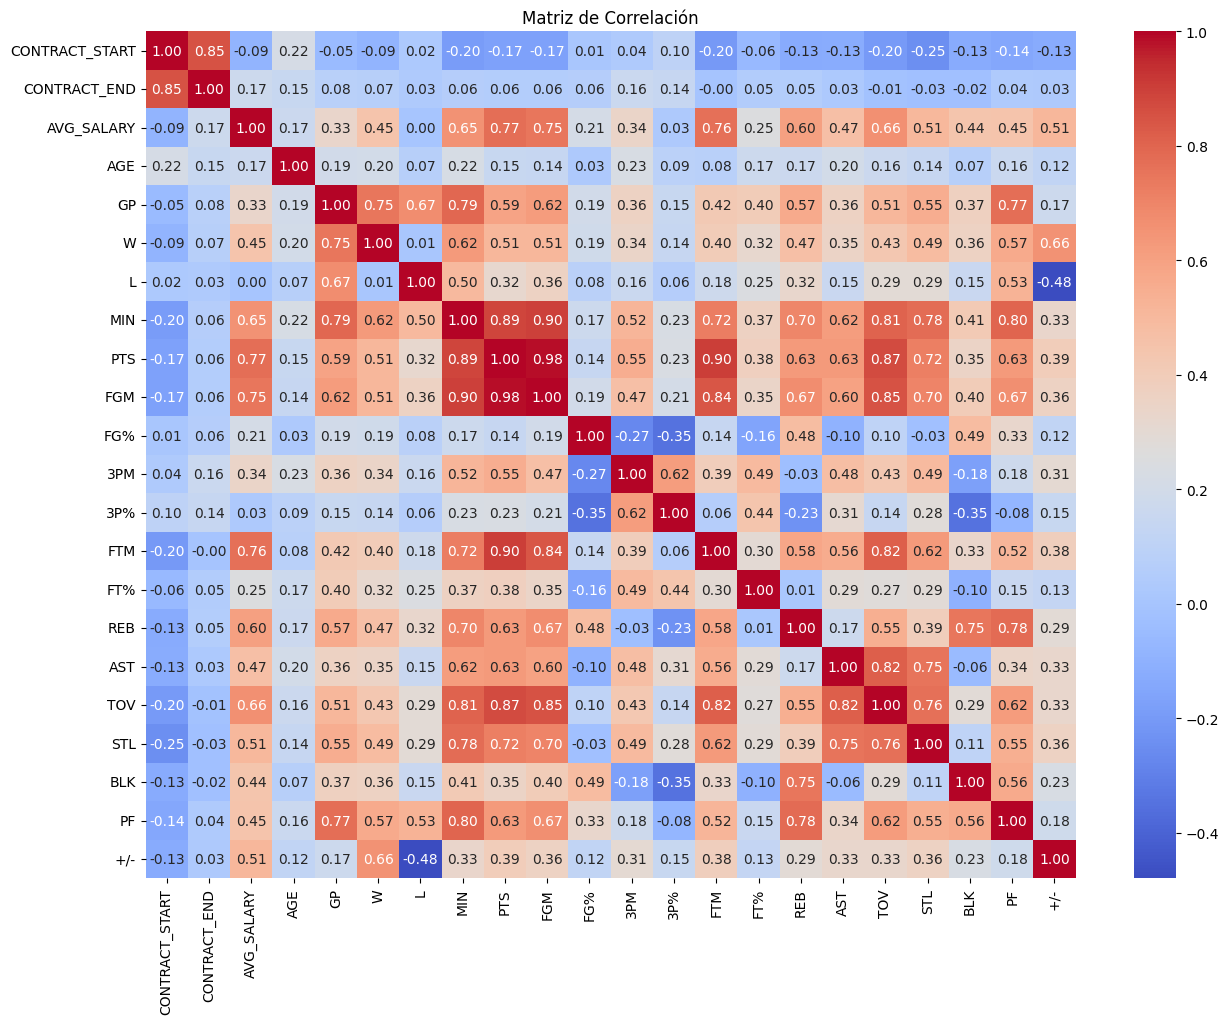

In [44]:
#Matriz de correlacion de datos
corr_matrix = df.corr()

# Heatmap de correlación de datos
plt.figure(figsize=(15, 11))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()

# **Pasos de PCA:**

1. Obtenemos datos:

**Explicación:** Obtenemos los datos de nuestro dataframe, separamos el target en `Y`, y las otras variables columnas en `X`.

In [45]:
x = df.drop(columns=["AVG_SALARY"])
y = df["AVG_SALARY"]

2. Data standardisation:

**Explicación:** Aquí estandarizamos las variables por medio de la siguiente fórmula, esto para evitar que la variación de rango de números en los datos afecte los pesos que se le den en la matriz de covarianza y en por siguiente en los demás pasos del proceso, al estandarizarlo todos los datos se rigen en un mismo rango y contribuyen lo mismo.

**Formula:**
$$
X_{z} = \frac{X - \mu}{\sigma}
$$

- $X_{z}$ = X estandarizada
- $x$ = Columnas independientes
- $\mu$ = Promedio de x
- $\sigma$ = Desviacion estandar de x



In [46]:
X_standar = (x - x.mean()) / x.std()
Y_standar = (y - y.mean()) / y.std()

3. Covariance matrix:

**Explicación:** Como siguiente paso obtenemos la matriz de covarianza de las variables `X`, esto para ver como se mueven nuestras variables y como se relacionan entre ellas, al haber estandarizado nuestros valores estos son muy similares a los de la correlación, podemos notar una especial relación entre las variables 6, 7 y 8, que son `MIN` (minutos de juego), `PTS` (Puntos), y `FGM` (Canastas anotadas), y también entre las variables 15 16 y 17, que son `AST` (Asistencia), `TOV` (Perdidas del balón) y `STL` (Robos del balón), los valores positivos significan que si una de las variables sube la otra también, negativa que si una sube la otra baja, y cercano a 0 que no tienen relación.

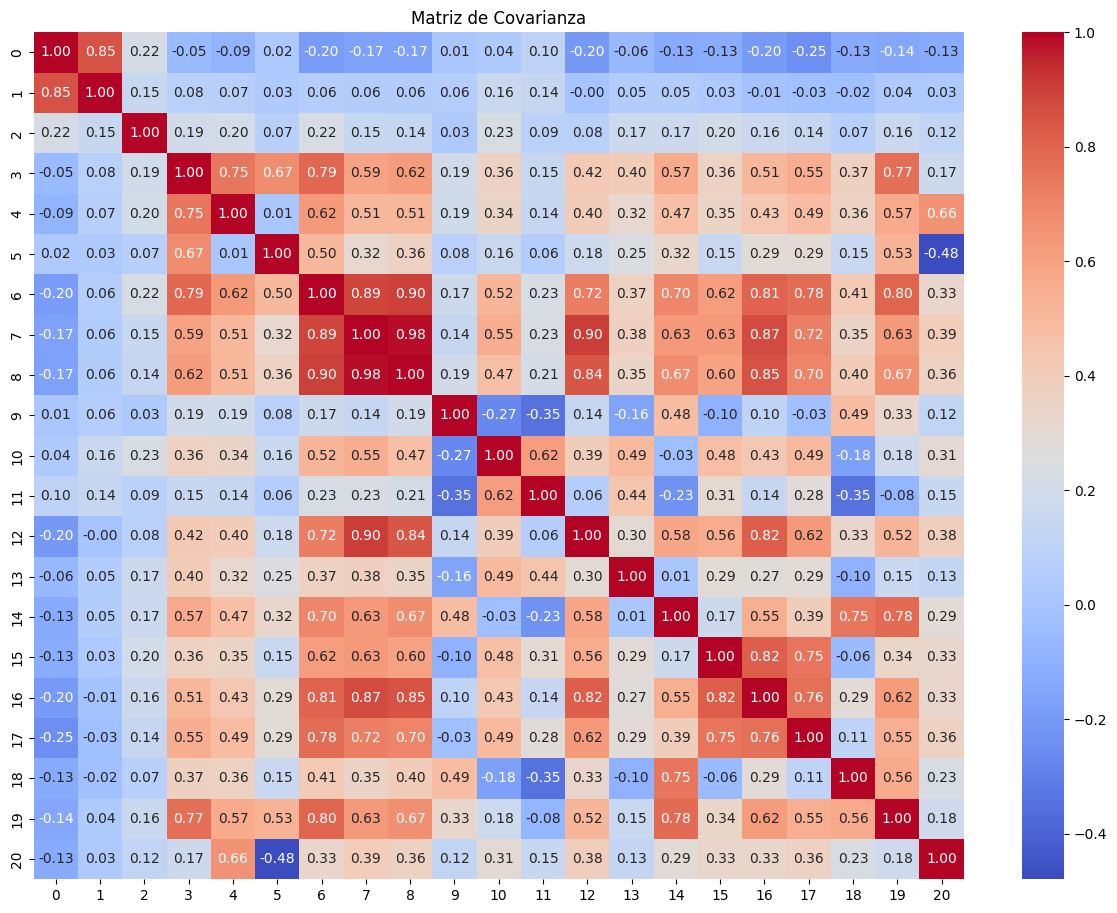

In [47]:
cov_matrix = np.cov(X_standar, rowvar=False) #Cada columna es una variable y las filas observaciones
plt.figure(figsize=(15, 11))
sns.heatmap(cov_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Covarianza")
plt.show()

4. Eigenvalues and eigenvectors:

**Explicación:** Para seguir con el procedimiento hay que sacar los eigenvalues y los eigenvectores, los eigenvectores son las direcciones hacia donde los datos no se salen de una misma línea al aplicar una transformación lineal, y el eigenvalue es la magnitud del como se moverían los datos al estar en estos vectores, es decir si tengo por ejemplo un dato en `(0,0)` y el vector es `[3, 0]`, este vector fue el que proporcionaba una mayor varianza, 3 en este caso, y el dato se movería 3 posiciones a la derecha, y lo mismo seria para cada dato en el eje X, el papel de esto en el PCA es que obtenemos estos datos para poder calcular nuevos valores moviéndolos con los eigenvectores y maximizando la varianza, para reducir la relación entre estos.

In [48]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix) #Funcion de numpy para sacar valores y vectores propios
print("Valores propios:\n", eigenvalues.round(2))
print("Vectores propios:\n", eigenvectors.round(2))

Valores propios:
 [-0.    0.    0.03  0.05  0.09  0.09  0.13  0.15  0.2   0.25  0.28  0.36
  0.53  0.58  0.75  0.9   1.23  1.78  2.05  3.    8.55]
Vectores propios:
 [[-0.   -0.    0.21 -0.28 -0.22 -0.44 -0.34  0.04  0.06  0.19 -0.02 -0.01
  -0.09 -0.02 -0.06 -0.06  0.21 -0.21  0.6   0.09  0.06]
 [ 0.    0.   -0.16  0.28  0.23  0.38  0.31 -0.05 -0.01 -0.26  0.01 -0.06
  -0.13 -0.02 -0.09 -0.21  0.24 -0.26  0.57  0.09 -0.02]
 [ 0.   -0.   -0.04  0.07  0.12  0.03  0.03 -0.04  0.06  0.02  0.12  0.02
   0.07 -0.06  0.25  0.89 -0.13 -0.14  0.24  0.07 -0.08]
 [-0.03  0.71 -0.08  0.09 -0.    0.09 -0.03  0.07  0.17  0.27  0.02  0.12
  -0.1   0.05 -0.24 -0.05 -0.37  0.18  0.2  -0.06 -0.27]
 [ 0.02 -0.52 -0.05  0.02 -0.15  0.05  0.14 -0.31  0.08  0.32  0.06  0.1
  -0.18  0.03 -0.28 -0.07 -0.46 -0.29  0.02 -0.03 -0.23]
 [ 0.02 -0.47 -0.07  0.12  0.16  0.09 -0.2   0.44  0.17  0.04 -0.04  0.07
   0.05  0.03 -0.05 -0.   -0.04  0.59  0.27 -0.06 -0.14]
 [ 0.   -0.    0.81 -0.26  0.1   0.15  0.31  0.04

5.  Transformation matrix:

**Explicación:** Como paso siguiente tenemos que ordenar los eigenvectores con los eigenvalues, de mayar a menor, generamos la matriz de transformación que nos servirá para cambiar los valores de los datos, los ordenamos para así tener los que tienen un mayor efecto en la varianza primero, ya que no vamos a tomar en cuenta todos los vectores solo los más altos.

In [49]:
#Ordenamos eigenvectors
indice = np.argsort(eigenvalues)[::-1] #Sacamos el indice para ordenarlos de mayor a menor
eigenvalues = eigenvalues[indice] #Ordenamos eigenvalues
F = eigenvectors[:, indice] #Ordenamos eigenvectors y obtenemos la matriz de transformacion
print("Matriz de transformacion:\n", F.round(2))

Matriz de transformacion:
 [[ 0.06  0.09  0.6  -0.21  0.21 -0.06 -0.06 -0.02 -0.09 -0.01 -0.02  0.19
   0.06  0.04 -0.34 -0.44 -0.22 -0.28  0.21 -0.   -0.  ]
 [-0.02  0.09  0.57 -0.26  0.24 -0.21 -0.09 -0.02 -0.13 -0.06  0.01 -0.26
  -0.01 -0.05  0.31  0.38  0.23  0.28 -0.16  0.    0.  ]
 [-0.08  0.07  0.24 -0.14 -0.13  0.89  0.25 -0.06  0.07  0.02  0.12  0.02
   0.06 -0.04  0.03  0.03  0.12  0.07 -0.04 -0.    0.  ]
 [-0.27 -0.06  0.2   0.18 -0.37 -0.05 -0.24  0.05 -0.1   0.12  0.02  0.27
   0.17  0.07 -0.03  0.09 -0.    0.09 -0.08  0.71 -0.03]
 [-0.23 -0.03  0.02 -0.29 -0.46 -0.07 -0.28  0.03 -0.18  0.1   0.06  0.32
   0.08 -0.31  0.14  0.05 -0.15  0.02 -0.05 -0.52  0.02]
 [-0.14 -0.06  0.27  0.59 -0.04 -0.   -0.05  0.03  0.05  0.07 -0.04  0.04
   0.17  0.44 -0.2   0.09  0.16  0.12 -0.07 -0.47  0.02]
 [-0.33 -0.01  0.04  0.08 -0.03 -0.   -0.05 -0.06  0.11  0.01  0.02 -0.12
  -0.01  0.04  0.31  0.15  0.1  -0.26  0.81 -0.    0.  ]
 [-0.32  0.04 -0.04 -0.01  0.18 -0.11  0.22 -0.07  0.04 

6. Explained variance:

**Explicación:** Calculamos los porcentajes de varianza de cada componente, podemos ver que solo con el primero ya se explica un 40.73% de varianza, con las primeras dos 55.03% y con las primeras tres 64.88%, ya con estas 3 primeras explicaríamos la mayor parte de la varianza, si quisiéramos explicar el 100% necesitaríamos de las primeras 19 variables.

**Formula:**
$$
V_{\lambda_j} = \frac{\lambda_j}{\sum_{i=1}^{M} \lambda_i}
$$

- $V_{\lambda_j}$ = Varianza del valor propio j
- ${\lambda_j}$ = Valor propio j
- $M$ = Cantidad de valores propios
- ${\lambda_j}$ = Valor propio i


In [50]:
#Aplicamos la formula
explained_var = (eigenvalues / eigenvalues.sum()) * 100
print("Porcentages de Varianza:\n", explained_var.round(2))

#Hacemos el acumulado tambien para ver como va subiendo
acumulado = np.cumsum(explained_var)
print("Porcentages acumulados de Varianza: \n", acumulado.round(2))

Porcentages de Varianza:
 [40.73 14.3   9.77  8.46  5.85  4.29  3.56  2.76  2.51  1.71  1.33  1.18
  0.95  0.72  0.63  0.45  0.41  0.25  0.15  0.   -0.  ]
Porcentages acumulados de Varianza: 
 [ 40.73  55.03  64.8   73.26  79.11  83.39  86.95  89.71  92.22  93.94
  95.26  96.44  97.39  98.11  98.74  99.19  99.6   99.85 100.   100.
 100.  ]


7. First three Componente Principals:

**Explicación:** Ya con nuestra matriz de transformación podemos aplicar el cambio de datos con los primeros 3 componentes aplicando la formula, en la siguiente tabla podemos ver como quedaron estos componentes como nuevos valores, los valores tienen un rango mucho menor comparado a los valores originales y varios ahora son negativos.

**Formula:**
$$
X_{pca} = X_{z} F
$$

- $X_{pca}$ = Valores de X como componentes principales
- $X_{z}$ = X estandarizada
- $F$ = Matriz de transformación


In [51]:
principales_3 = pd.DataFrame(X_standar.dot(F[:, :3])) #Los primeros 3 arreglos
principales_3.head()

,0,1,2
0,-0.203810,1.950078,2.969223
1,-1.389671,-2.816381,0.425962
2,-0.338059,-5.588658,-1.498913
3,-2.821814,-0.417820,0.379123
4,-3.365355,-3.739402,2.372014


**Explicación:** Graficamos los datos de los primeros 3 componentes, al ser 3 es un gráfico en tercera dimensiones en el cual podemos ver que los datos ya no cuentan con relación entre sí, y se encuentran dispersos sin ninguna tendencia aparente por todo el cubo o plano 3D.

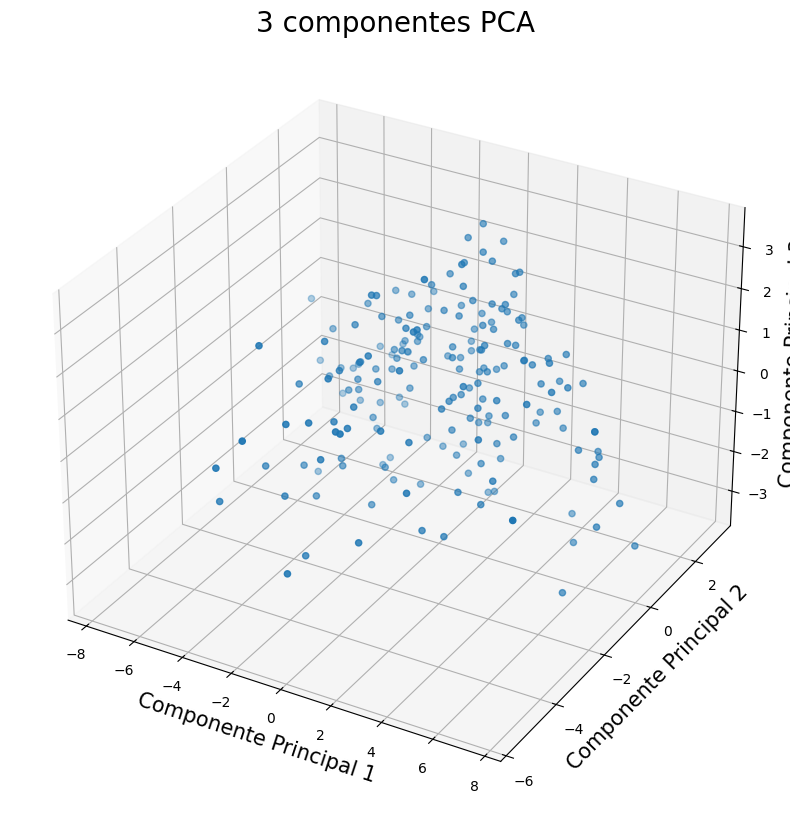

In [52]:
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(principales_3[0], principales_3[1], principales_3[2])
ax.set_xlabel('Componente Principal 1', fontsize=15)
ax.set_ylabel('Componente Principal 2', fontsize=15)
ax.set_zlabel('Componente Principal 3', fontsize=15)
ax.set_title('3 componentes PCA', fontsize=20)
ax.grid(True)
plt.show()


8. First two Componente Principals:

**Explicación:** Al igual que en el paso anterior pasamos a transformar los datos, pero ahora solo con 2 componentes para generar nuevos datos, y teniendo un gráfico en 2 dimensiones, en la siguiente tabla podemos ver como quedaron estos componentes como nuevos valores, los valores tienen un rango mucho menor comparado a los valores originales y varios ahora son negativos.

**Formula:**
$$
X_{pca} = X_{z} F
$$

- $X_{pca}$ = Valores de X como componentes principales
- $X_{z}$ = X estandarizada
- $F$ = Matriz de transformación


In [53]:
principales_2 = pd.DataFrame(X_standar.dot(F[:, :2])) #Los primeros 2 arreglos
principales_2.head()

,0,1
0,-0.203810,1.950078
1,-1.389671,-2.816381
2,-0.338059,-5.588658
3,-2.821814,-0.417820
4,-3.365355,-3.739402


**Explicación:** Ahora graficamos los datos de los primeros 2 componentes, al ser 2 es un plano en segunda dimensión, en el cual podemos ver que los datos ya no cuentan con una fuerte relación, si cierta tendencia hacia una parte del gráfico pero no una relación clara, ya que se encuentran esparcidos por todo el plano.

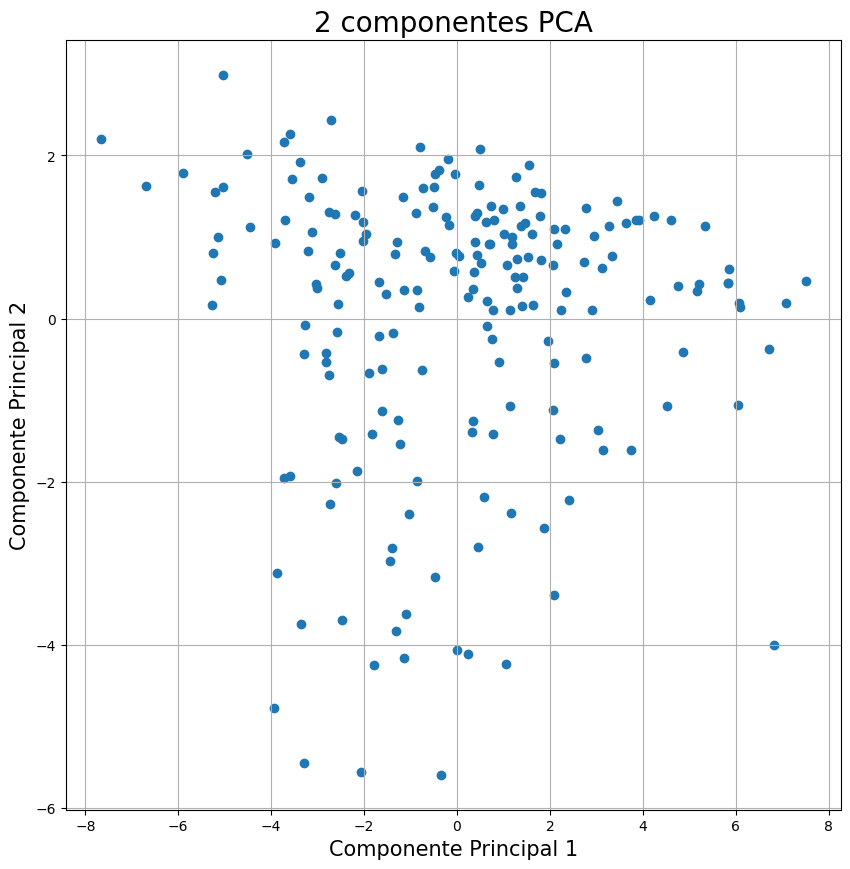

In [54]:
fig = plt.figure(figsize = (10,10))
ax = fig.add_subplot(1,1,1)
ax.scatter(principales_2[0], principales_2[1])
ax.set_xlabel('Componente Principal 1', fontsize=15)
ax.set_ylabel('Componente Principal 2', fontsize=15)
ax.set_title('2 componentes PCA', fontsize=20)
ax.grid(True)
plt.show()


**Extra:** Para verificar que los datos ya no tienen relación entre sí después de realizar el proceso de PCA hacemos una matriz de correlación, podemos ver que el proceso funciono muy bien en dataset y la correlación son en su mayoría en 0 al visualizar todos los componentes.

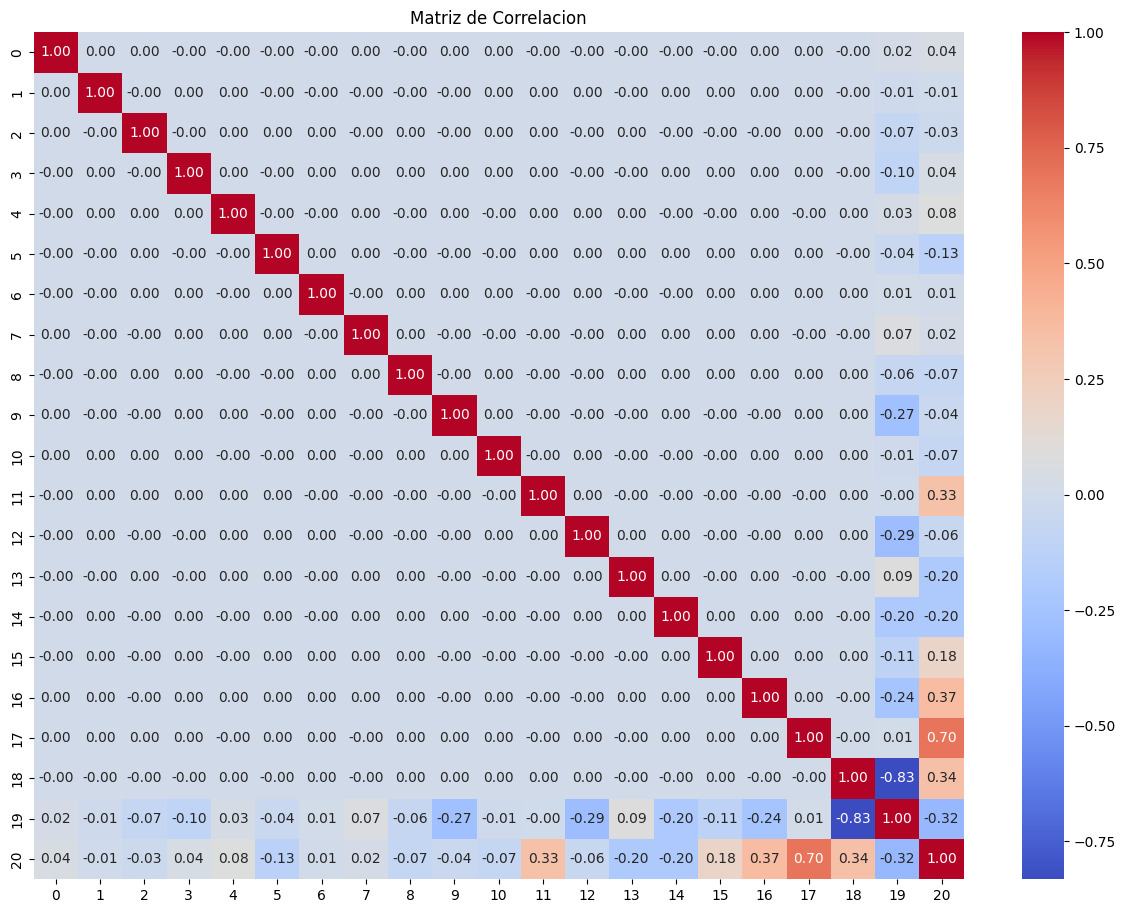

In [55]:
plt.figure(figsize=(15, 11))
corr_matrix = (X_standar.dot(F)).corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlacion")
plt.show()

# **Conclusiones:**
Después de haber realizado esta actividad me queda más claro el proceso por el que pasa el PCA, ya que tuve que realizar manualmente cada paso del proceso, desde la estandarización, los valores propios, la matriz de transformación y la derivada de los nuevos datos, el proceso de PCA fue efectivo para reducir la correlación entre variables y la colinealidad que podía existir, además de simplificar los datos y los valores a considerar, por lo que ahora este dataset se ve factible para su aplicación en un modelo de redes neuronales de regresión.

# **Link Github:**
- https://github.com/antoniorivag/02-Principal-Component-Analysis

# **Fuente base de datos:**
- Current NBA players contracts history. (2021, February 8). https://www.kaggle.com/datasets/jarosawjaworski/current-nba-players-contracts-history

# **Referencias APA:**
- Galarnyk, M. (2024, February 23). PCA using Python: A tutorial. Built In. https://builtin.com/machine-learning/pca-in-python
- Numpy.linalg.eig — NumPy v2.1 Manual. (n.d.). https://numpy-org.translate.goog/doc/2.1/reference/generated/numpy.linalg.eig.html?_x_tr_sl=en&_x_tr_tl=es&_x_tr_hl=es&_x_tr_pto=tc
- 3Blue1Brown. (2016, September 15). Eigenvectors and eigenvalues | Chapter 14, Essence of linear algebra [Video]. YouTube. https://www.youtube.com/watch?v=PFDu9oVAE-g

**Codigo de honor:** "Doy mi palabra que he realizado esta actividad con integridad academica"